In [28]:
%%bash

source Metadata-Copy1.sh
set -euo pipefail


# ============================================================
# FINAL POINT-CLOUD RECONSTRUCTION WITH parallel_stereo
# ============================================================
#
# FINAL_STEREO_MODE="single"
#     Runs all entries in FINAL_SINGLE_PAIRS.
#
# FINAL_STEREO_MODE="dual"
#     Runs all ordered three-image configurations in
#     FINAL_DUAL_CONFIGURATIONS.
#
# FINAL_STEREO_MODE="tri"
#     Automatically runs AB, AC, and BC, then merges the three
#     point clouds into one ABACBC point cloud.
#
# This cell generates point clouds only.
# Final DSM generation is performed in the following step.
# ============================================================


# Store successfully generated point clouds
GENERATED_POINT_CLOUDS=()


# ============================================================
# 1. FIND THE ARRAY INDEX OF A VIEW
# ============================================================

get_view_index() {

    local requested_view="$1"
    local index

    for index in "${!VIEW_IDS[@]}"; do

        if [[ "${VIEW_IDS[$index]}" == "${requested_view}" ]]; then
            printf '%s\n' "${index}"
            return 0
        fi

    done

    echo "ERROR: View ${requested_view} is not available." >&2
    echo "Available views: ${VIEW_IDS[*]}" >&2

    return 1
}


# ============================================================
# 2. PREPARE ONE STEREO OR MERGE OUTPUT DIRECTORY
# ============================================================

prepare_stereo_run() {

    local run_directory="$1"
    local log_file="$2"

    if [[ -e "${run_directory}" || -e "${log_file}" ]]; then

        if [[ "${OVERWRITE_OUTPUTS}" == true ]]; then

            echo ""
            echo "Removing previous outputs:"
            echo "  ${run_directory}"

            rm -rf -- "${run_directory}"
            rm -f -- "${log_file}"

        else

            echo "ERROR: Outputs already exist:" >&2
            echo "  ${run_directory}" >&2
            echo "" >&2
            echo "Set OVERWRITE_OUTPUTS=true to replace them." >&2

            return 1

        fi

    fi

    mkdir -p \
        "${run_directory}" \
        "$(dirname "${log_file}")"
}


# ============================================================
# 3. RUN ONE STEREO CONFIGURATION
# ============================================================

run_stereo_configuration() {

    local configuration_type="$1"
    local configuration_definition="$2"

    local -a configuration_views=()
    local -a map_images=()
    local -a rpc_cameras=()

    local view
    local view_index
    local configuration_tag=""

    local kernel_index
    local ck
    local sk

    local outname
    local run_directory
    local run_prefix
    local point_cloud
    local log_file


    # --------------------------------------------------------
    # Read a definition such as:
    #
    #   "A B"
    #   "A B C"
    # --------------------------------------------------------

    read -r -a configuration_views <<< \
        "${configuration_definition}"


    # --------------------------------------------------------
    # Validate configuration length
    # --------------------------------------------------------

    case "${configuration_type}" in

        single)

            if (( ${#configuration_views[@]} != 2 )); then

                echo "ERROR: A single configuration requires" >&2
                echo "exactly two views:" >&2
                echo "  ${configuration_definition}" >&2

                return 1

            fi
            ;;


        dual)

            if (( ${#configuration_views[@]} != 3 )); then

                echo "ERROR: A dual configuration requires" >&2
                echo "exactly three ordered views:" >&2
                echo "  ${configuration_definition}" >&2

                return 1

            fi
            ;;


        *)

            echo "ERROR: Unsupported configuration type:" >&2
            echo "  ${configuration_type}" >&2

            return 1
            ;;

    esac


    # --------------------------------------------------------
    # Identify map-projected images and original RPC cameras
    # --------------------------------------------------------

    for view in "${configuration_views[@]}"; do

        view_index="$(get_view_index "${view}")"

        configuration_tag+="${view}"

        map_images+=(
            "${MAPPROJECTED_IMAGES[$view_index]}"
        )

        rpc_cameras+=(
            "${RPC_FILES[$view_index]}"
        )

    done


    # --------------------------------------------------------
    # Validate required inputs
    # --------------------------------------------------------

    require_files \
        "${MAPPROJECT_DEM}" \
        "${map_images[@]}" \
        "${rpc_cameras[@]}"


    echo ""
    echo "============================================================"
    echo "STEREO CONFIGURATION: ${configuration_tag}"
    echo "============================================================"
    echo "Type               : ${configuration_type}"
    echo "Views              : ${configuration_views[*]}"
    echo "Algorithm          : ${FINAL_STEREO_ALGORITHM}"
    echo "Cost mode          : ${FINAL_COST_MODE}"
    echo "Mapprojection DEM  : ${MAPPROJECT_DEM}"
    echo "Point-cloud folder : ${FINAL_POINT_CLOUD_OUTPUT_DIR}"
    echo "============================================================"


    # --------------------------------------------------------
    # Run all paired correlation/subpixel kernel settings
    # --------------------------------------------------------

    for kernel_index in "${!FINAL_CKERNELS[@]}"; do

        ck="${FINAL_CKERNELS[$kernel_index]}"
        sk="${FINAL_SKERNELS[$kernel_index]}"


        # Example:
        # Berared_Aug24_BM_ck9_sk21
        outname="${area_name}_${FINAL_ALGORITHM_TAG}_ck${ck}_sk${sk}"


        # Example:
        # point_clouds/stereo_AB_Berared_Aug24_BM_ck9_sk21/
        run_directory="${FINAL_POINT_CLOUD_OUTPUT_DIR}/stereo_${configuration_tag}_${outname}"


        # Example:
        # .../AB_Berared_Aug24_BM_ck9_sk21
        run_prefix="${run_directory}/${configuration_tag}_${outname}"


        # Expected parallel_stereo point cloud
        point_cloud="${run_prefix}-PC.tif"


        # Stereo log
        log_file="${LOG_DIR}/stereo.${configuration_tag}_${outname}.log"


        # ----------------------------------------------------
        # Prepare output directory
        # ----------------------------------------------------

        prepare_stereo_run \
            "${run_directory}" \
            "${log_file}"


        echo ""
        echo "------------------------------------------------------------"
        echo "Running configuration : ${configuration_tag}"
        echo "Correlation kernel    : ${ck} x ${ck}"
        echo "Subpixel kernel       : ${sk} x ${sk}"
        echo "Output prefix         : ${run_prefix}"
        echo "Expected point cloud  : ${point_cloud}"
        echo "------------------------------------------------------------"
        echo ""


        # ----------------------------------------------------
        # Run stereo reconstruction
        # ----------------------------------------------------
        #
        # Input order:
        #
        #   map-projected images
        #   corresponding original RPC files
        #   output prefix
        #   DEM used during map projection
        # ----------------------------------------------------

        parallel_stereo \
            -t "${CAMERA_SESSION}" \
            --alignment-method none \
            --stereo-algorithm "${FINAL_STEREO_ALGORITHM}" \
            --xcorr-threshold "${FINAL_XCORR_THRESHOLD}" \
            --cost-mode "${FINAL_COST_MODE}" \
            --corr-kernel "${ck}" "${ck}" \
            --subpixel-kernel "${sk}" "${sk}" \
            --corr-tile-size "${corr_tile_size}" \
            --corr-memory-limit-mb "${corr_mem_limit_mb}" \
            --subpixel-mode "${spr}" \
            --bundle-adjust-prefix "${ALIGNED_BA_PREFIX}" \
            "${map_images[@]}" \
            "${rpc_cameras[@]}" \
            "${run_prefix}" \
            "${MAPPROJECT_DEM}" \
            2>&1 | tee "${log_file}"


        # ----------------------------------------------------
        # Confirm point-cloud creation
        # ----------------------------------------------------

        require_files "${point_cloud}"


        GENERATED_POINT_CLOUDS+=(
            "${point_cloud}"
        )


        echo ""
        echo "Completed point cloud:"
        echo "  ${point_cloud}"

    done
}


# ============================================================
# 4. RUN ACTIVE SINGLE-PAIR CONFIGURATIONS
# ============================================================
#
# Used by:
#
#   FINAL_STEREO_MODE="single"
#
# and:
#
#   FINAL_STEREO_MODE="tri"
#
# In tri mode, the metadata automatically supplies:
#   A B
#   A C
#   B C
# ============================================================

for configuration_definition in "${ACTIVE_SINGLE_PAIRS[@]}"; do

    run_stereo_configuration \
        "single" \
        "${configuration_definition}"

done


# ============================================================
# 5. RUN ACTIVE ORDERED THREE-IMAGE CONFIGURATIONS
# ============================================================
#
# Used only by:
#
#   FINAL_STEREO_MODE="dual"
#
# Examples:
#   A B C
#   B A C
#   C A B
# ============================================================

for configuration_definition in \
    "${ACTIVE_DUAL_CONFIGURATIONS[@]}"
do

    run_stereo_configuration \
        "dual" \
        "${configuration_definition}"

done


# ============================================================
# 6. MERGE AB, AC, AND BC IN TRI-STEREO MODE
# ============================================================
#
# Used only when:
#
#   FINAL_STEREO_MODE="tri"
#
# Inputs:
#   AB point cloud
#   AC point cloud
#   BC point cloud
#
# Output:
#   ABACBC merged point cloud
# ============================================================

if [[ "${TRI_MERGE_REQUIRED}" == true ]]; then

    for kernel_index in "${!FINAL_CKERNELS[@]}"; do

        ck="${FINAL_CKERNELS[$kernel_index]}"
        sk="${FINAL_SKERNELS[$kernel_index]}"

        outname="${area_name}_${FINAL_ALGORITHM_TAG}_ck${ck}_sk${sk}"


        # ----------------------------------------------------
        # Find the three pairwise point clouds
        # ----------------------------------------------------

        pair_point_clouds=()

        for pair_tag in "${TRI_MERGE_PAIR_TAGS[@]}"; do

            pair_point_cloud="${FINAL_POINT_CLOUD_OUTPUT_DIR}/stereo_${pair_tag}_${outname}/${pair_tag}_${outname}-PC.tif"

            require_files "${pair_point_cloud}"

            pair_point_clouds+=(
                "${pair_point_cloud}"
            )

        done


        # ----------------------------------------------------
        # Define merged output
        # ----------------------------------------------------

        merged_directory="${TRI_MERGED_POINT_CLOUD_OUTPUT_DIR}/merged_${TRI_MERGE_TAG}_${outname}"

        merged_point_cloud="${merged_directory}/${TRI_MERGE_TAG}_${outname}-PC.tif"

        merge_log="${LOG_DIR}/pc_merge.${TRI_MERGE_TAG}_${outname}.log"


        # ----------------------------------------------------
        # Prepare merged output
        # ----------------------------------------------------

        prepare_stereo_run \
            "${merged_directory}" \
            "${merge_log}"


        echo ""
        echo "============================================================"
        echo "MERGE TRI-STEREO POINT CLOUDS"
        echo "============================================================"
        echo "Input pairs        : ${TRI_MERGE_PAIR_TAGS[*]}"
        echo "Algorithm          : ${FINAL_STEREO_ALGORITHM}"
        echo "Correlation kernel : ${ck} x ${ck}"
        echo "Subpixel kernel    : ${sk} x ${sk}"
        echo "Merged point cloud : ${merged_point_cloud}"
        echo "============================================================"
        echo ""


        # ----------------------------------------------------
        # Merge AB, AC, and BC point clouds
        # ----------------------------------------------------

        pc_merge \
            "${pair_point_clouds[@]}" \
            -o "${merged_point_cloud}" \
            --threads "${FINAL_PC_MERGE_THREADS}" \
            --tif-compress LZW \
            2>&1 | tee "${merge_log}"


        # ----------------------------------------------------
        # Confirm merged point-cloud creation
        # ----------------------------------------------------

        require_files "${merged_point_cloud}"


        GENERATED_POINT_CLOUDS+=(
            "${merged_point_cloud}"
        )


        echo ""
        echo "Merged tri-stereo point cloud completed:"
        echo "  ${merged_point_cloud}"

    done

fi


# ============================================================
# 7. FINAL SUMMARY
# ============================================================

echo ""
echo "============================================================"
echo "POINT-CLOUD RECONSTRUCTION COMPLETED"
echo "============================================================"
echo "Mode             : ${FINAL_STEREO_MODE}"
echo "Algorithm        : ${FINAL_STEREO_ALGORITHM}"
echo "Output directory : ${FINAL_POINT_CLOUD_OUTPUT_DIR}"
echo ""

for point_cloud in "${GENERATED_POINT_CLOUDS[@]}"; do
    echo "${point_cloud}"
done

echo "============================================================"


STEREO CONFIGURATION: CAB
Type               : dual
Views              : C A B
Algorithm          : asp_mgm
Cost mode          : 4
Mapprojection DEM  : /mnt/summer/USERS/KOAI/Berared_Aug24/LiDAR_DEMs/Ellps/Berared_LiDAR_DSM50m_WGS84_31N.tif
Point-cloud folder : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/point_clouds

------------------------------------------------------------
Running configuration : CAB
Correlation kernel    : 9 x 9
Subpixel kernel       : 21 x 21
Output prefix         : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/point_clouds/stereo_CAB_Berared_Aug24_MGM_ck9_sk21/CAB_Berared_Aug24_MGM_ck9_sk21
Expected point cloud  : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/point_clouds/stereo_CAB_Berared_Aug24_MGM_ck9_sk21/CAB_Berared_Aug24_MGM_ck9_sk21-PC.tif
------------------------------------------------------------

sed: /mnt/summer/USERS/KOAI/ASP/StereoPipeline-3.3.0-Linux/lib/libselinux.so.1: no version information available (req

In [29]:
%%bash

source Metadata-Copy1.sh
set -euo pipefail


# ============================================================
# FINAL DSM GENERATION
# ============================================================
#
# This cell reads all point-cloud selections from the metadata.
#
# Single mode:
#   Creates one DSM for every selected single pair.
#
# Dual mode:
#   Creates one DSM for every selected ordered configuration.
#
# Tri mode:
#   Creates one DSM from the merged AB + AC + BC point cloud.
#
# All outputs are placed in:
#   FINAL_DSM_OUTPUT_DIR
# ============================================================


# ============================================================
# 1. VALIDATE USER PARAMETERS
# ============================================================

if [[ "${FINAL_DSM_CREATE_ERROR_IMAGE}" != true \
      && "${FINAL_DSM_CREATE_ERROR_IMAGE}" != false ]]; then

    echo "ERROR: FINAL_DSM_CREATE_ERROR_IMAGE must be true or false." >&2
    exit 1

fi


if (( $(echo "${FINAL_DSM_RESOLUTION} <= 0" | bc -l) )); then

    echo "ERROR: FINAL_DSM_RESOLUTION must be larger than zero." >&2
    exit 1

fi


if (( $(echo "${FINAL_MAX_VALID_TRIANGULATION_ERROR} < 0" | bc -l) )); then

    echo "ERROR: FINAL_MAX_VALID_TRIANGULATION_ERROR cannot be negative." >&2
    exit 1

fi


mkdir -p "${FINAL_DSM_OUTPUT_DIR}"


# ============================================================
# 2. BUILD THE LIST OF POINT CLOUDS TO RASTERIZE
# ============================================================

FINAL_POINT_CLOUDS=()
FINAL_PRODUCT_TAGS=()
FINAL_PRODUCT_CK=()
FINAL_PRODUCT_SK=()


register_point_cloud() {

    local product_tag="$1"
    local ck="$2"
    local sk="$3"
    local point_cloud="$4"

    require_files "${point_cloud}"

    FINAL_PRODUCT_TAGS+=(
        "${product_tag}"
    )

    FINAL_PRODUCT_CK+=(
        "${ck}"
    )

    FINAL_PRODUCT_SK+=(
        "${sk}"
    )

    FINAL_POINT_CLOUDS+=(
        "${point_cloud}"
    )
}


for kernel_index in "${!FINAL_CKERNELS[@]}"; do

    ck="${FINAL_CKERNELS[$kernel_index]}"
    sk="${FINAL_SKERNELS[$kernel_index]}"

    outname="${area_name}_${FINAL_ALGORITHM_TAG}_ck${ck}_sk${sk}"


    case "${FINAL_STEREO_MODE}" in

        single)

            for product_tag in "${ACTIVE_SINGLE_PAIR_TAGS[@]}"; do

                point_cloud="${FINAL_POINT_CLOUD_OUTPUT_DIR}/stereo_${product_tag}_${outname}/${product_tag}_${outname}-PC.tif"

                register_point_cloud \
                    "${product_tag}" \
                    "${ck}" \
                    "${sk}" \
                    "${point_cloud}"

            done
            ;;


        dual)

            for product_tag in \
                "${ACTIVE_DUAL_CONFIGURATION_TAGS[@]}"
            do

                point_cloud="${FINAL_POINT_CLOUD_OUTPUT_DIR}/stereo_${product_tag}_${outname}/${product_tag}_${outname}-PC.tif"

                register_point_cloud \
                    "${product_tag}" \
                    "${ck}" \
                    "${sk}" \
                    "${point_cloud}"

            done
            ;;


        tri)

            product_tag="${TRI_MERGE_TAG}"

            point_cloud="${TRI_MERGED_POINT_CLOUD_OUTPUT_DIR}/merged_${product_tag}_${outname}/${product_tag}_${outname}-PC.tif"

            register_point_cloud \
                "${product_tag}" \
                "${ck}" \
                "${sk}" \
                "${point_cloud}"
            ;;


        *)

            echo "ERROR: Unsupported FINAL_STEREO_MODE:" >&2
            echo "  ${FINAL_STEREO_MODE}" >&2
            exit 1
            ;;

    esac

done


if (( ${#FINAL_POINT_CLOUDS[@]} == 0 )); then

    echo "ERROR: No final point clouds were selected." >&2
    exit 1

fi


# ============================================================
# 3. GENERATE ONE DSM FOR EACH SELECTED POINT CLOUD
# ============================================================

GENERATED_DEMS=()


for product_index in "${!FINAL_POINT_CLOUDS[@]}"; do

    point_cloud="${FINAL_POINT_CLOUDS[$product_index]}"
    product_tag="${FINAL_PRODUCT_TAGS[$product_index]}"
    ck="${FINAL_PRODUCT_CK[$product_index]}"
    sk="${FINAL_PRODUCT_SK[$product_index]}"


    outname="${area_name}_${FINAL_ALGORITHM_TAG}_ck${ck}_sk${sk}"


    # Example:
    # AB_Berared_Aug24_BM_ck9_sk21-1.0m
    dem_name="${product_tag}_${outname}-${FINAL_DSM_RESOLUTION}m"


    # Every DSM is stored in the same final_dsms directory
    dem_prefix="${FINAL_DSM_OUTPUT_DIR}/${dem_name}"

    expected_dem="${dem_prefix}-DEM.tif"

    expected_error_image="${dem_prefix}-IntersectionErr.tif"

    log_file="${LOG_DIR}/point2dem.${dem_name}.log"


    # --------------------------------------------------------
    # Prepare output
    # --------------------------------------------------------

    prepare_output_prefix \
        "${dem_prefix}" \
        "${log_file}"


    echo ""
    echo "============================================================"
    echo "GENERATE FINAL DSM"
    echo "============================================================"
    echo "Product                    : ${product_tag}"
    echo "Input point cloud          : ${point_cloud}"
    echo "Algorithm                  : ${FINAL_STEREO_ALGORITHM}"
    echo "Correlation kernel         : ${ck} × ${ck}"
    echo "Subpixel kernel            : ${sk} × ${sk}"
    echo "DSM resolution             : ${FINAL_DSM_RESOLUTION} m"
    echo "Triangulation-error limit  : ${FINAL_MAX_VALID_TRIANGULATION_ERROR} m"
    echo "Output DSM                 : ${expected_dem}"
    echo "============================================================"
    echo ""


    # --------------------------------------------------------
    # Build point2dem options
    # --------------------------------------------------------

    point2dem_options=(
        --max-valid-triangulation-error
        "${FINAL_MAX_VALID_TRIANGULATION_ERROR}"

        --t_srs
        "${proj}"

        --tr
        "${FINAL_DSM_RESOLUTION}"

        --threads
        "${FINAL_DSM_THREADS}"

        --nodata-value
        "${FINAL_DSM_NODATA}"

        --tif-compress
        "${FINAL_DSM_COMPRESSION}"
    )


    if [[ "${FINAL_DSM_CREATE_ERROR_IMAGE}" == true ]]; then

        point2dem_options+=(
            --errorimage
        )

    fi


    # --------------------------------------------------------
    # Generate DSM
    # --------------------------------------------------------

    point2dem \
        "${point2dem_options[@]}" \
        "${point_cloud}" \
        -o "${dem_prefix}" \
        2>&1 | tee "${log_file}"


    # --------------------------------------------------------
    # Validate outputs
    # --------------------------------------------------------

    require_files "${expected_dem}"


    if [[ "${FINAL_DSM_CREATE_ERROR_IMAGE}" == true ]]; then

        require_files "${expected_error_image}"

    fi


    GENERATED_DEMS+=(
        "${expected_dem}"
    )


    echo ""
    echo "Final DSM completed:"
    echo "  ${expected_dem}"

done


# ============================================================
# 4. FINAL SUMMARY
# ============================================================

echo ""
echo "============================================================"
echo "FINAL DSM GENERATION COMPLETED"
echo "============================================================"
echo "Output directory:"
echo "  ${FINAL_DSM_OUTPUT_DIR}"
echo ""

for generated_dem in "${GENERATED_DEMS[@]}"; do
    echo "${generated_dem}"
done

echo "============================================================"

bash: line 39: bc: command not found
bash: line 47: bc: command not found



GENERATE FINAL DSM
Product                    : CAB
Input point cloud          : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/point_clouds/stereo_CAB_Berared_Aug24_MGM_ck9_sk21/CAB_Berared_Aug24_MGM_ck9_sk21-PC.tif
Algorithm                  : asp_mgm
Correlation kernel         : 9 × 9
Subpixel kernel            : 21 × 21
DSM resolution             : 1.0 m
Triangulation-error limit  : 1.0 m
Output DSM                 : /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/final_dsms/CAB_Berared_Aug24_MGM_ck9_sk21-1.0m-DEM.tif

	--> Setting number of processing threads to: 4
Writing log info to: /mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/final_dsms/CAB_Berared_Aug24_MGM_ck9_sk21-1.0m-log-point2dem-07-15-1223-134259.txt
Statistics: [********************************************************] Complete!
Bounding box and triangulation error range estimation: [*************] Complete!
QuadTree: [**********************************************************] Comple


Selected configuration:
  CAB_Berared_Aug24_MGM_ck9_sk21-1.0m
    Acquisition geometry: BFM (Backward–Forward–Middle)

PDF figure saved to:
/mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/Figure/Berared_Aug24_final_DSM_and_intersection_error.pdf


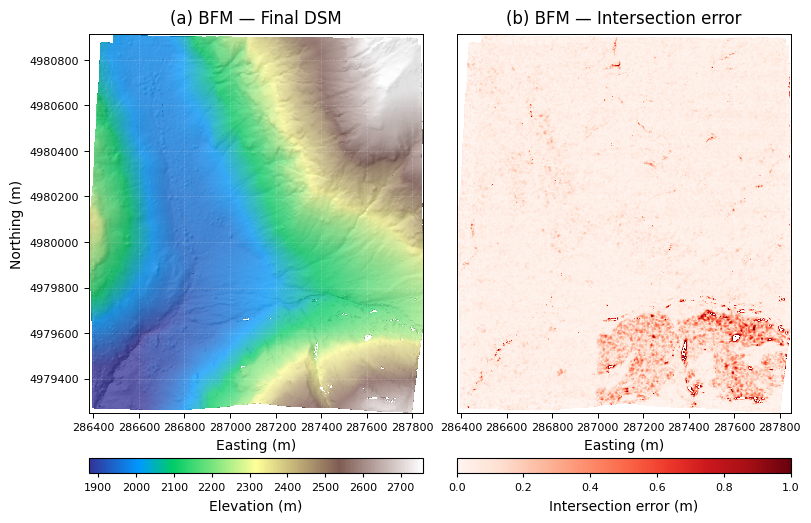

PosixPath('/mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/Figure/Berared_Aug24_final_DSM_and_intersection_error.pdf')

In [8]:
from importlib import reload
import asp_workflow_utils as asp_utils

reload(asp_utils)

asp_utils.plot_final_dsm(
    "Metadata-Copy1.sh",

    show_grid=True,
    grid_color="white",
    grid_alpha=0.22,
    grid_linewidth=0.5,
    grid_linestyle="--",
    grid_spacing=None,

    return_images=False,
)


Selected final DSM configuration:
  CAB_Berared_Aug24_MGM_ck9_sk21-1.0m
  Acquisition geometry: BFM

Accuracy data:
  File: /mnt/summer/USERS/KOAI/Sensors_Data_DEMs_LaBerarde/Analysis_1m/Berarde_coreg_pixel_dod_long.csv
  Product: Pleiades_2024
  Before stage: Before
  After stage: After_Nuth

Before co-registration:
  RMSE: 4.474 m
  NMAD: 0.342 m

After co-registration:
  RMSE: 0.382 m
  NMAD: 0.344 m

PDF figure saved to:
/mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/Figure/Berared_Aug24_BFM_DSM_intersection_error_Pleiades_vertical_residuals.pdf


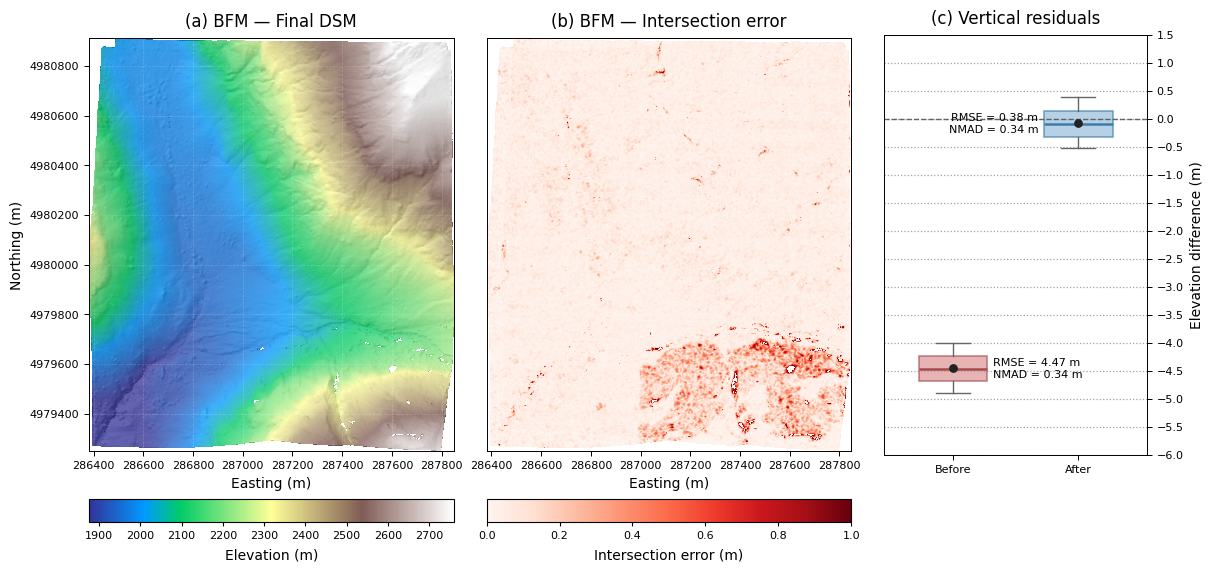

PosixPath('/mnt/summer/USERS/KOAI/Berared_Aug24/cropped_data/asp_out/Figure/Berared_Aug24_BFM_DSM_intersection_error_Pleiades_vertical_residuals.pdf')

In [10]:
from importlib import reload
import asp_workflow_utils as asp_utils

reload(asp_utils)

asp_utils.plot_final_dsm_accuracy_figure(
    "Metadata-Copy1.sh",

    accuracy_file=(
        "/mnt/summer/USERS/KOAI/"
        "Sensors_Data_DEMs_LaBerarde/"
        "Analysis_1m/"
        "Berarde_coreg_pixel_dod_long.csv"
    ),

    show_grid=True,
    grid_spacing=None,

    # Panel (c): one horizontal line every 0.5 m
    accuracy_grid_spacing=0.5,
    show_accuracy_grid=True,

    return_data=False,
)